# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [7]:
# a) Primeras filas
display(df.head())

# b) Resumen estadístico
display(df.describe())

# c) Canciones por género
display(df["playlist_genre"].value_counts())

# d) Valores faltantes
faltantes = df.isna().sum()
display(faltantes[faltantes > 0])

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,3.245900
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2.710000
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2.943600
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2.818217
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,3.150867


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,3.763330
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182,0.997233
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,0.066667
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000,3.130317
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000,3.600000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000,4.226417
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,8.630167


playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

track_name          5
track_artist        5
track_album_name    5
dtype: int64

### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

> R= Los 6 generos mostrados en general estan bastante parejos entre sus valores, por lo tanto no hay ninguno que destaque muchisimo en comparación a su valor anterior. Bajo mi perspectiva es importante la comparación ya que si uno de los generos tuviera un valor mucho menor de canciones con respecto al resto, se podria volver mas prospecto a valores atipicos y por la tanto haria menos confiable la información, en su defecto esta comparacion estaria mas influenciada mas que nada por el tamaño de la muestra que por una diferencia real.

**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

> R= Si en la fila de "min" hay una captura que muestra un valor de 0.066667 minutos que son mas o menos 4 segundos, es bastante sospechoso ya que una cancion es imposible que dure tan poco tiempo. Lo mas probable es que sea un erro de captura.

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

Media :  0.6986192707032558
Mediana:  0.721
Desviación estándar :  0.18091003391959107
Rango:  0.999825


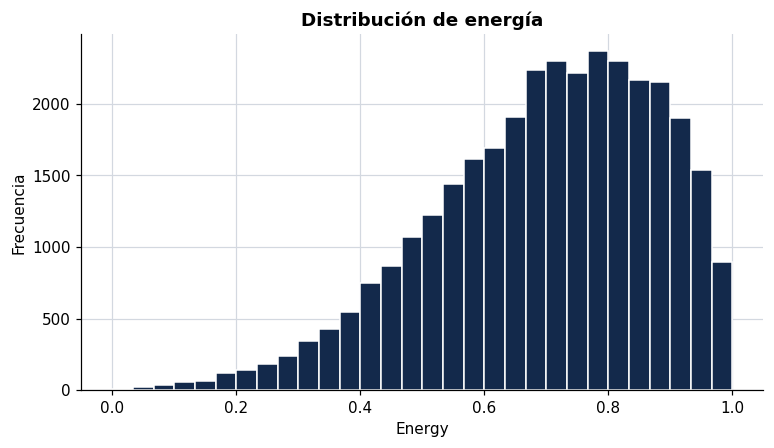

Skew:  -0.6363298409581105


In [18]:
# a) Media, mediana, desviación estándar y rango de energy
media = df["energy"].mean()
mediana = df["energy"].median()
dev_estandar =df["energy"].std()
rango = df["energy"].max() - df["energy"].min()

print("Media : ", media)
print("Mediana: ", mediana)
print("Desviación estándar : ", dev_estandar)
print("Rango: ", rango)

# b) Histograma

plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Energy")
plt.ylabel("Frecuencia")
plt.title("Distribución de energía")
plt.show()

# c) Asimetría
skew = df["energy"].skew()
print("Skew: ", skew)

### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

> R= La variable Energy tiene una media de 0.699, una mediana de 0.721, una desviación estandar de 0.18 y rango que va de 0 a 0.999 que redondeados seria 1.

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

> R= La media si quedo por debajo de la mediana como muestran los valores mencionados anteriormente. Esto nos indica que los valores de la cola se extienden hacia la izquierda donde estan los valores bajos. Esto lo confirmamos con el skew ya que este nos muestra un valor negativo (-0.6363), y con el histograma lo visualizamos que la cola mas larga esta hacia la izquierda.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

                    mean       std
playlist_genre                    
edm             0.802476  0.139415
rock            0.732813  0.194501
latin           0.708312  0.152308
pop             0.701028  0.171084
rap             0.650708  0.170340
r&b             0.590934  0.179407


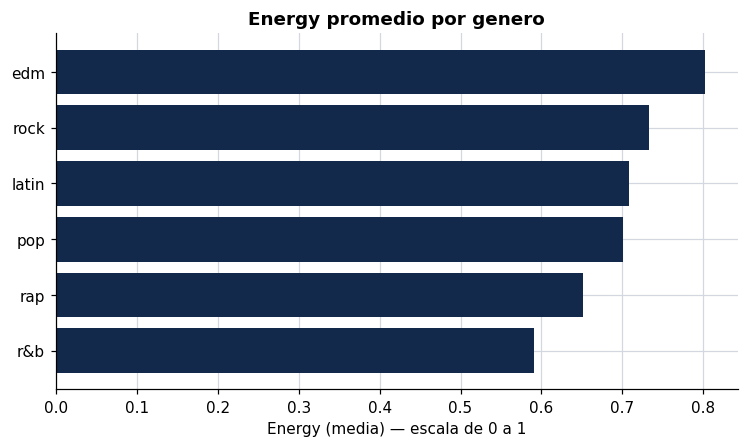

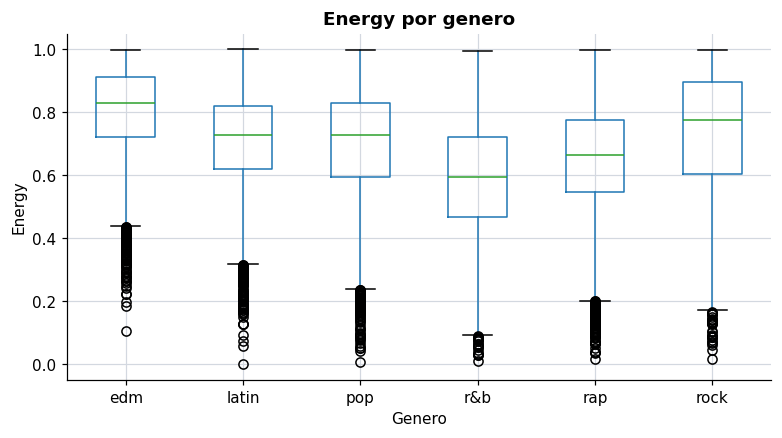

In [23]:
# a) Media y desviación de energy por género
energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean", "std"]).sort_values("mean", ascending=False)
print(energia_genero)

# b) Gráfico de barras horizontales
serie = energia_genero["mean"].sort_values()
plt.barh(serie.index, serie.values, color=AZUL)
plt.xlabel("Energy (media) — escala de 0 a 1")
plt.title("Energy promedio por genero")
plt.show()

# c) Boxplot
df.boxplot(column="energy", by="playlist_genre")
plt.xlabel("Genero")
plt.ylabel("Energy")
plt.title("Energy por genero")
plt.suptitle("") 
plt.show()


### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

> R= El mas energio es "edm" con 0.802 de media y el que menos el "r&b" con una media de 0.590.

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

> R= El genero mas disperso es el "rock" con una dispersion de 0.195, a diferencia del mas energetico que es el "edm". En pocas palabras que un genero tenga mucha dispersion quiere decir que en terminos energeticos las canciones de ese genero son muy diferentes entre si, y que tenga poca significa que son muy parecidas.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

> R= Mi respuesta es que como esta no, lo que hize fue agregarle una seccion adicional a la etiqueta para que pueda visualizarse la escala que tiene el mismo grafico. Una persona que lee el informe a lo mejor puede ver el grafico y no sabe que los valores solo pueden rondar entre 0 y 1 en terminos de energia.

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

Más negativo: ('acousticness', 'energy') -> -0.5397446301909388
Más positivo: ('energy', 'loudness') -> 0.6766245234442312


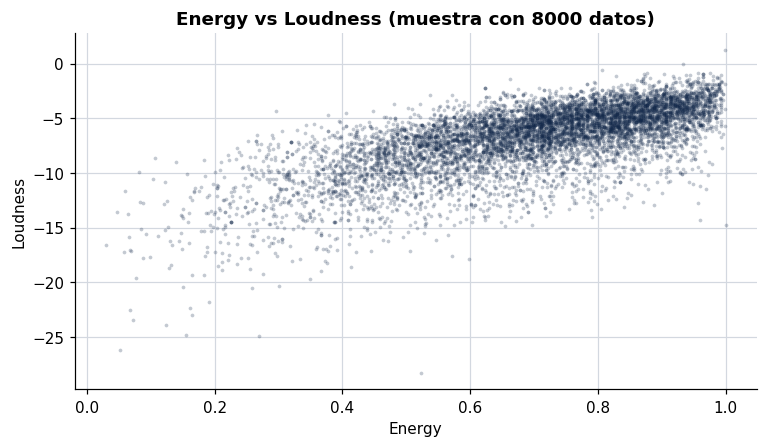

instrumentalness   -0.149872
duration_min       -0.143682
energy             -0.109112
liveness           -0.054584
tempo              -0.005378
speechiness         0.006819
valence             0.033231
loudness            0.057687
danceability        0.064748
acousticness        0.085159
track_popularity    1.000000
Name: track_popularity, dtype: float64


In [31]:
# a) Matriz de correlación
corr = df[audio].corr()

# b) Lista de pares ordenada: el más positivo y el más negativo
pares = corr.unstack()
pares = pares[pares < 0.999]                                              
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  
pares = pares.sort_values()
print("Más negativo:", pares.index[0], "->", pares.iloc[0])
print("Más positivo:", pares.index[-1], "->", pares.iloc[-1])

# c) Diagrama de dispersión del par más positivo
m = df.sample(8000, random_state=1)
plt.scatter(m["energy"], m["loudness"], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("Energy")
plt.ylabel("Loudness")
plt.title("Energy vs Loudness (muestra con 8000 datos)")
plt.show()

# d) Correlación de cada variable de audio con track_popularity
pop_corr = df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()
print(pop_corr)


### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

> R= El par con la correlación positiva más fuerte es energy y loudness, con 0.677 y el par con la correlación negativa más fuerte es acousticness y energy, con -0.540.

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

> R= Aunque esta es la correlación más alta entre las 45 variables analizadas, la relación no es perfecta. Al observar la nube de puntos se nota que los datos están bastante dispersos y no forman una línea recta definida. Esto indica que la correlación describe una tendencia general: las canciones con mayor nivel de energy suelen presentar también un loudness más alto. Sin embargo, esta relación no es lo suficientemente fuerte como para predecir con exactitud el nivel de loudness de una canción específica únicamente a partir de su energy.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

> R= No se puede afirmar que una variable cause a la otra solo por la correlación. Antes de eso hay que descartar: (1) una variable oculta mueva a ambas — por ejemplo, la forma en que se mezcla y masteriza un género musical podría hacer que las canciones sean simultáneamente más intensas (energy) y más fuertes en volumen (loudness); (2) causa invertida — que un mayor volumen de mezcla haga que la canción "suene" más energética, en vez de al revés; y (3) coincidencia — poco probable aquí dado lo fuerte de la relación, pero siempre hay que considerarla. Con los datos que tenemos, solo podemos decir que están asociadas, no que una cause la otra.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

> R= La variable que mas correlaciona es "instrumentalness", pero en este la correlacion es negativa por ende es muy debil. Esto apenas representa una parte minima de la variacion en popularidad, asi que no creo que nos sirva de mucho para poder dar una predicción concreta.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [37]:
# a) Correlación global entre energy y danceability
r_global = df["energy"].corr(df["danceability"])
print("Conjunto completo:",r_global)

# b) La misma correlación dentro de cada género
corr_genero = df.groupby("playlist_genre").apply(
    lambda g: g["energy"].corr(g["danceability"])
).sort_values()
print(corr_genero)

# c) Tabla resumen por género
tabla = pd.concat([
    energia_genero["mean"].rename("energy_mean"),
    df.groupby("playlist_genre")["danceability"].mean().rename("dance_mean"),
    df.groupby("playlist_genre")["track_popularity"].mean().rename("pop_mean"),
    corr_genero.rename("corr_energy_dance")
], axis=1).sort_values("energy_mean", ascending=False)
print(tabla)

# d) Estandarización de energy y canción más extrema

df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()
idx = df["energy_z"].idxmax()
print(df.loc[idx, ["track_name", "track_artist", "playlist_genre", "energy", "energy_z"]])

print("media z:", df["energy_z"].mean(), "  std z:", df["energy_z"].std())
print("skew z:", df["energy_z"].skew(), "  skew original:", df["energy"].skew())


Conjunto completo: -0.08607315593777042
playlist_genre
rock    -0.152882
edm     -0.150262
rap     -0.148173
pop     -0.030729
latin    0.115939
r&b      0.159201
dtype: float64
                energy_mean  dance_mean   pop_mean  corr_energy_dance
playlist_genre                                                       
edm                0.802476    0.655041  34.833526          -0.150262
rock               0.732813    0.520548  41.728338          -0.152882
latin              0.708312    0.713287  47.026576           0.115939
pop                0.701028    0.639302  47.744870          -0.030729
rap                0.650708    0.718353  43.215454          -0.148173
r&b                0.590934    0.670179  41.223532           0.159201
track_name        Rain Forest and Tropical Beach Sound
track_artist                Nature Sounds Nature Music
playlist_genre                                   latin
energy                                             1.0
energy_z                                  

C:\Users\DANI SALDAÑA\AppData\Local\Temp\ipykernel_4804\4052621980.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_genero = df.groupby("playlist_genre").apply(


### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

> R= La r en el conjunto completo vale -0.086, el genero mas negativo es el "rock" con -0.153, y el mas positivo es el "r&b" con 0.159.

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

> R= Una correlación general cercana a cero no significa que energy y danceability no estén relacionadas. Lo que ocurre es que, al analizar todos los géneros juntos, las tendencias de algunos géneros se compensan con las de otros. Por ejemplo, en géneros como rock, EDM y rap, las canciones más energéticas suelen ser menos bailables, mientras que en latin y R&B sucede lo contrario. Al combinar todos los géneros en un solo análisis, estas relaciones opuestas se neutralizan y la correlación global parece casi inexistente. En este caso, el género musical actúa como un factor que influye en ambas variables y puede ocultar las relaciones reales dentro de cada grupo, un fenómeno conocido como la paradoja de Simpson.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

> R= Los datos muestran que una mayor energía no necesariamente se traduce en una mayor popularidad. Aunque el género EDM tiene el nivel promedio de energy más alto, también presenta la popularidad promedio más baja entre los géneros analizados. En contraste, el género pop alcanza la mayor popularidad con un nivel de energía más moderado. Esto sugiere que aumentar la energía de las canciones, por sí solo, no parece ser una estrategia efectiva para hacerlas más populares, ya que en este conjunto de datos ambas variables no muestran una relación positiva clara.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

> R= La canción con el valor de energy_z más alto se encuentra 1.67 desviaciones estándar por encima del promedio de energía. Además, la asimetría (skewness) de energy_z es exactamente la misma que la de la variable original energy. Esto ocurre porque la estandarización solo cambia la escala de los datos y establece una nueva referencia para el promedio, pero no modifica la forma de la distribución. En otras palabras, aunque los valores se expresen de manera diferente, la distribución conserva el mismo nivel de sesgo hacia un lado.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

> Tras analizar más de 32,800 canciones, encontramos que subirle la "energía" a las canciones no parece ser una vía confiable para hacerlas más populares. Según los promedios por género del Ejercicio 5(c), el género con la energía promedio más alta es el edm (0.80 sobre 1), pero es justo el que tiene la popularidad promedio más baja (35 sobre 100), mientras que el pop, con una energía más moderada (0.70), es el género más popular en promedio (48 sobre 100). Además, como vimos en el Ejercicio 5(b), la relación entre energía y qué tan bailable es una canción cambia según el género: en rock y edm, más energía se asocia con canciones menos bailables, pero en r&b ocurre justo lo contrario. Por eso, si solo miráramos el dato combinado de todos los géneros (Ejercicio 5a) —que sugiere casi ninguna relación entre ambas variables—, estaríamos escondiendo que en realidad sí hay una relación clara, solo que va en direcciones distintas según el estilo musical. Como advertencia: estos datos muestran asociaciones entre las canciones que ya existen y su popularidad, pero no nos permiten concluir que cambiar la energía de una canción específica vaya a cambiar cuánto le va a gustar a la gente; para eso haría falta un experimento, no solo observar lo que ya está en el catálogo.


---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

> Ejericio 3 (c): En este mas que nada lo use porque en la grafica de Boxplot aparecia un titulo predeterminado el cual no me permitia dejar que la etiqueta que puse apreciara del todo bien. Por ende le pregunte IA como hacer para quitar dicho titulo y me paso la siguiente linea "plt.suptitle("")", esta funciona para quitar el predeterminado que agrega PANDAS.

> Ejercicio 5 (c): Este código junta cuatro resultados que ya tenías calculados por separado (media de energy, media de danceability, media de track_popularity, y la correlación energy-danceability) en una sola tabla, alineándolos por género y ordenándolos de mayor a menor energía, para poder comparar todo de un vistazo Sabía qué operación necesitaba (correlación por grupo, estandarización), pero no recordaba la sintaxis exacta de pandas (.groupby().apply(), pd.concat()), así que consulté cómo escribirla. Tampoco pude entender del todo bien que es lo que estaba solicitando con usando las variables de genero en conjunto con la correlacion energia y baile.

---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.